In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os
meme_path = '/content/drive/MyDrive/memes '
images = [f for f in os.listdir(meme_path) if f.endswith('.jpg')]
print(f"✅ Total images found: {len(images)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Total images found: 975


In [6]:
!pip install torch torchvision open-clip-torch faiss-cpu -q

import open_clip
import torch
from PIL import Image
import numpy as np
import pickle
from tqdm import tqdm

# CLIP model load
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
model.eval()

embeddings = []
valid_images = []

for img_name in tqdm(images):
    try:
        img_path = f'{meme_path}/{img_name}'
        img = preprocess(Image.open(img_path).convert('RGB')).unsqueeze(0)
        with torch.no_grad():
            emb = model.encode_image(img).numpy()[0]
        embeddings.append(emb)
        valid_images.append(img_name)
    except:
        pass

embeddings = np.array(embeddings).astype('float32')
print(f"✅ Embeddings done: {len(embeddings)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.8 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
100%|██████████| 975/975 [03:52<00:00,  4.20it/s]

✅ Embeddings done: 975


In [7]:
import faiss

# Index বানাও
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings)

# Save করুন
faiss.write_index(index, '/content/drive/MyDrive/memes_index.faiss')

with open('/content/drive/MyDrive/memes_meta.pkl', 'wb') as f:
    pickle.dump(valid_images, f)

print(f"✅ Index saved! Total: {index.ntotal} images indexed")

✅ Index saved! Total: 975 images indexed


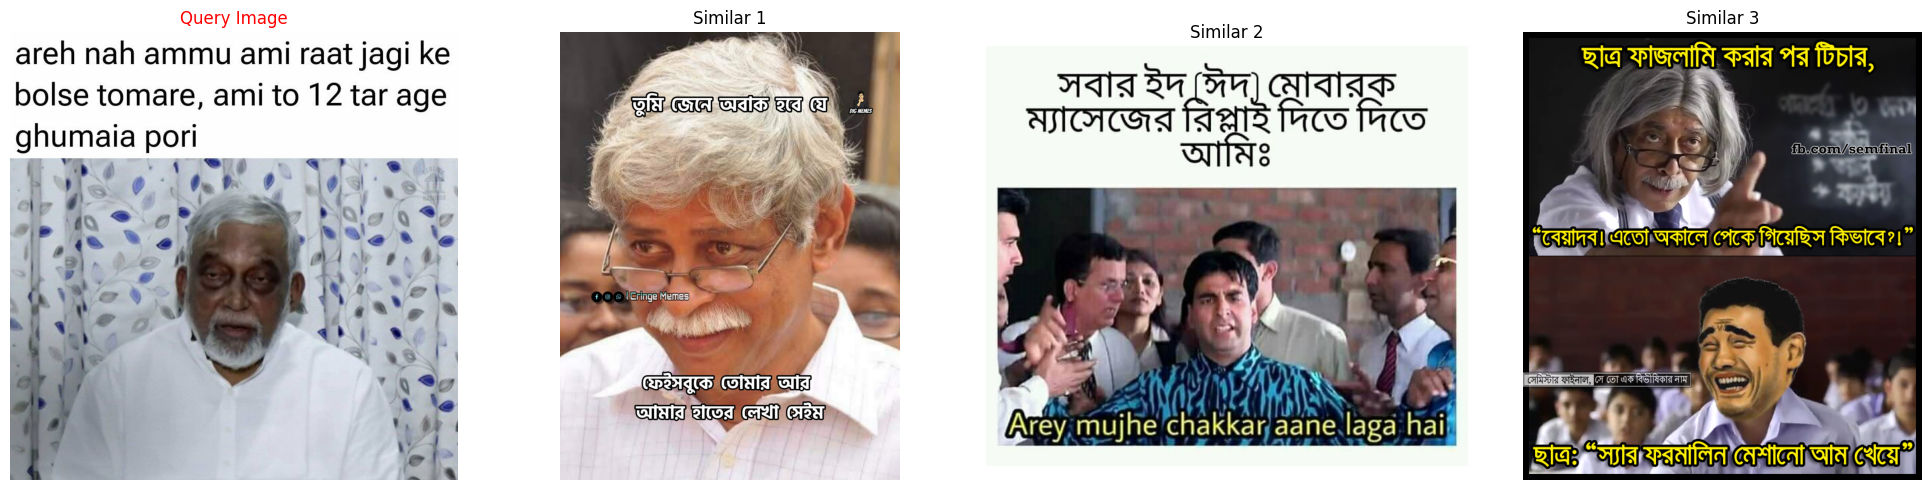

✅ Similar memes found!


In [8]:
# একটা image দিয়ে test করি
test_img_name = valid_images[0]
test_img = preprocess(Image.open(f'{meme_path}/{test_img_name}').convert('RGB')).unsqueeze(0)

with torch.no_grad():
    test_emb = model.encode_image(test_img).numpy().astype('float32')

# Similar 3টা খুঁজুন
D, I = index.search(test_emb, 4)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Query image
axes[0].imshow(Image.open(f'{meme_path}/{test_img_name}'))
axes[0].set_title('Query Image', color='red')
axes[0].axis('off')

# Similar images
for i, idx in enumerate(I[0][1:]):
    axes[i+1].imshow(Image.open(f'{meme_path}/{valid_images[idx]}'))
    axes[i+1].set_title(f'Similar {i+1}')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()
print("✅ Similar memes found!")

In [11]:
from openai import OpenAI
import base64
import os

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key="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",
)

meme_path = '/content/drive/MyDrive/memes '
test_img = os.listdir(meme_path)[0]

with open(f'{meme_path}/{test_img}', 'rb') as f:
    img_data = base64.b64encode(f.read()).decode()

response = client.chat.completions.create(
    model="meta-llama/llama-4-scout",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:image/jpeg;base64,{img_data}"}
                },
                {
                    "type": "text",
                    "text": "এই image দেখে একটা মজার বাংলা meme caption বানাও। শুধু caption দাও, অন্য কিছু না।"
                }
            ]
        }
    ]
)

print("✅ Caption:", response.choices[0].message.content)

✅ Caption: কথায় না বলে কাজে বুঝাও


In [12]:
from openai import OpenAI
import base64, os

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key="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",
)

# আপনার PC থেকে যেকোনো একটা image upload করুন
from google.colab import files
uploaded = files.upload()
img_name = list(uploaded.keys())[0]

with open(img_name, 'rb') as f:
    img_data = base64.b64encode(f.read()).decode()

response = client.chat.completions.create(
    model="meta-llama/llama-4-scout",
    messages=[{
        "role": "user",
        "content": [
            {
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{img_data}"}
            },
            {
                "type": "text",
                "text": "এই image দেখে একটা মজার বাংলা meme caption বানাও। শুধু caption দাও, অন্য কিছু না।"
            }
        ]
    }]
)

print("✅ Caption:", response.choices[0].message.content)

Saving ].heic to ].heic
✅ Caption: কাপড়টা ভালো হয়েছে, কিন্তু চেহারাটা বোকার মতো হয়েছে
